In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 0 Dirichlet BC

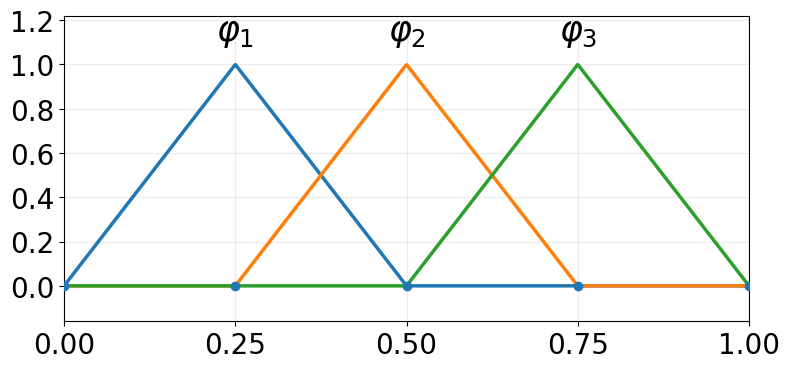

In [23]:
# Mesh on [0, 1]
n_elements = 4
nodes = np.linspace(0, 1, n_elements + 1)
x = np.linspace(0, 1, 1000)

def hat_function(i, x, nodes):
    """Piecewise-linear hat function centered at node i."""
    vals = np.zeros_like(x)

    left = nodes[i - 1]
    center = nodes[i]
    right = nodes[i + 1]

    rising = (x >= left) & (x <= center)
    falling = (x >= center) & (x <= right)

    vals[rising] = (x[rising] - left) / (center - left)
    vals[falling] = (right - x[falling]) / (right - center)

    return vals

plt.figure(figsize=(8, 3.8))

# Homogeneous Dirichlet BCs: basis functions only at interior nodes
for i in range(1, n_elements):
    y = hat_function(i, x, nodes)
    plt.plot(x, y, linewidth=2.5, label=rf"$\varphi_{i}$")
    plt.text(nodes[i], 1.07, rf"$\varphi_{i}$",
             ha="center", va="bottom", fontsize=25)

# Mark all mesh nodes
plt.scatter(nodes, np.zeros_like(nodes), zorder=3)


#plt.title("1D FEM hat basis functions with Vacuum boundary conditions")
#plt.xlabel(r"$x$")
#plt.ylabel(r"$\varphi_i(x)$")
plt.xlim(0, 1.0)
plt.ylim(-0.16, 1.22)
plt.grid(True, alpha=0.25)
plt.xticks([0,0.25,0.5,0.75,1.0], fontsize=20)
plt.yticks(fontsize=20)
#plt.legend(loc="upper right", ncol=1, frameon=False)
plt.tight_layout()

plt.savefig("1d_hat_functions_dirichlet.png", dpi=300, bbox_inches="tight")
plt.savefig("1d_hat_functions_dirichlet.pdf", bbox_inches="tight")

plt.show()

# Vacuum BCs

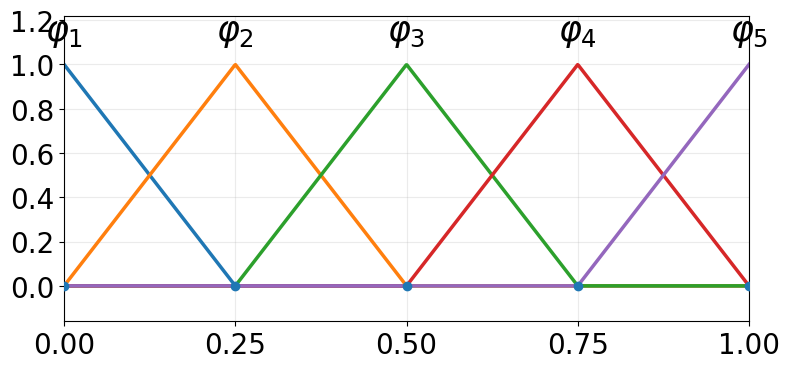

In [22]:
# Mesh on [0, 1]
n_elements = 4
nodes = np.linspace(-1/n_elements, 1 + 1/n_elements, n_elements + 3)
x = np.linspace(0, 1, 1000)

def hat_function(i, x, nodes):
    """Piecewise-linear hat function centered at node i."""
    vals = np.zeros_like(x)

    left = nodes[i - 1]
    center = nodes[i]
    right = nodes[i + 1]

    rising = (x >= left) & (x <= center)
    falling = (x >= center) & (x <= right)

    vals[rising] = (x[rising] - left) / (center - left)
    vals[falling] = (right - x[falling]) / (right - center)

    return vals

plt.figure(figsize=(8, 3.8))

# Homogeneous Dirichlet BCs: basis functions only at interior nodes
for i in range(1, n_elements+2):
    y = hat_function(i, x, nodes)
    plt.plot(x, y, linewidth=2.5, label=rf"$\varphi_{i}$")
    plt.text(nodes[i], 1.07, rf"$\varphi_{i}$",
             ha="center", va="bottom", fontsize=25)

# Mark all mesh nodes
plt.scatter(nodes, np.zeros_like(nodes), zorder=3)


#plt.title("1D FEM hat basis functions with Vacuum boundary conditions")
#plt.xlabel(r"$x$")
#plt.ylabel(r"$\varphi_i(x)$")
plt.xlim(0, 1.0)
plt.ylim(-0.16, 1.22)
plt.grid(True, alpha=0.25)
plt.xticks([0,0.25,0.5,0.75,1.0], fontsize=20)
plt.yticks(fontsize=20)
#plt.legend(loc="upper right", ncol=1, frameon=False)
plt.tight_layout()

plt.savefig("1d_hat_functions_dirichlet.png", dpi=300, bbox_inches="tight")
plt.savefig("1d_hat_functions_dirichlet.pdf", bbox_inches="tight")

plt.show()

2D basis functions

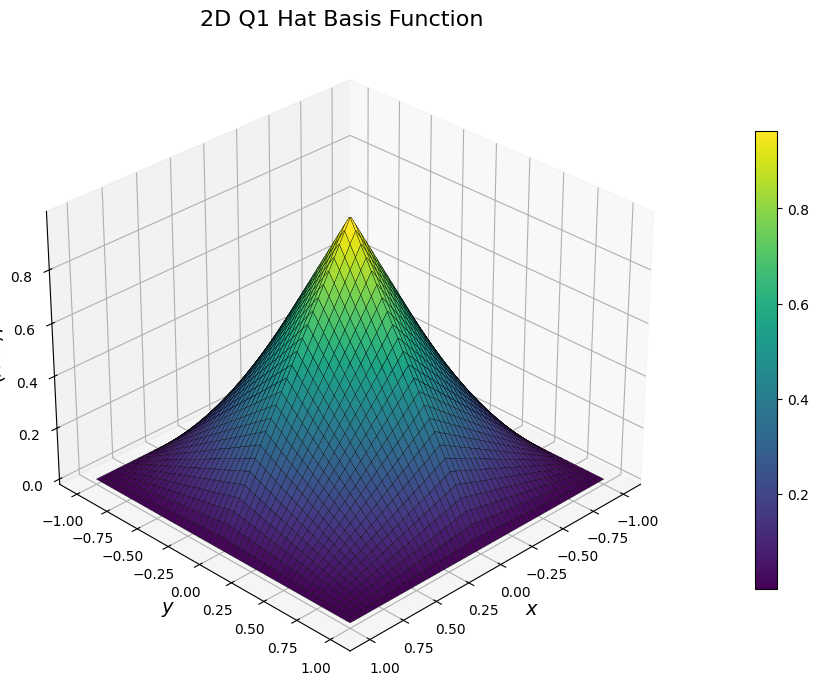

In [3]:
# ============================================================
# 2D Q1 hat basis function
# phi(x,y) = max(1-|x-x0|/h,0) * max(1-|y-y0|/h,0)
# ============================================================

# Mesh spacing
h = 1.0

# Center node location
x0 = 0.0
y0 = 0.0

# Create grid
N = 300
x = np.linspace(-h, h, N)
y = np.linspace(-h, h, N)

X, Y = np.meshgrid(x, y)

# 1D hat functions
phi_x = np.maximum(1 - np.abs(X - x0)/h, 0)
phi_y = np.maximum(1 - np.abs(Y - y0)/h, 0)

# 2D tensor-product hat function
Phi = phi_x * phi_y

# ============================================================
# Plot
# ============================================================

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X,
    Y,
    Phi,
    cmap='viridis',
    edgecolor='k',
    linewidth=0.25,
    antialiased=True
)

# Labels
ax.set_xlabel(r'$x$', fontsize=14)
ax.set_ylabel(r'$y$', fontsize=14)
ax.set_zlabel(r'$\phi(x,y)$', fontsize=14)

ax.set_title('2D Q1 Hat Basis Function', fontsize=16)

# Better viewing angle
ax.view_init(elev=30, azim=45)

# Color bar
fig.colorbar(surf, shrink=0.7, pad=0.1)

plt.tight_layout()
plt.show()